# Southern California - PFO Catalog Analysis
---

In [1]:
%%time
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
# Import packages as
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#-----------------------------------------------------------------------------------------------------------------#
# From package import
from pyproj import Geod
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

CPU times: user 2.44 s, sys: 5.51 s, total: 7.95 s
Wall time: 5.9 s


---
Read in regional catalog (up to 500 km)

In [2]:
def read_scedc_txt(path: str) -> pd.DataFrame:
    with open(path, "r") as f:
        lines = f.readlines()

    # Find header line
    header_idx = None
    for i, line in enumerate(lines):
        if line.strip().startswith("#YYY"):
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header line not found in {path}")

    # Extract column names
    colnames = lines[header_idx].strip().lstrip("#").split()

    # Collect only valid data lines
    data_lines = []
    for line in lines[header_idx + 1:]:
        line_strip = line.strip()
        if line_strip.startswith("# Number"):
            break
        if line_strip.startswith("</PRE>"):
            break
        if len(line_strip) == 0:
            continue
        data_lines.append(line_strip)

    # Convert to DataFrame
    from io import StringIO
    df = pd.read_csv(
        StringIO("\n".join(data_lines)),
        delim_whitespace=True,
        names=colnames,
        engine="python",
    )

    # Build timestamp
    df["time"] = pd.to_datetime(
        df["YYY/MM/DD"] + " " + df["HH:mm:SS.ss"],
        format="%Y/%m/%d %H:%M:%S.%f",
        errors="coerce"
    )

    return df

In [3]:
# Now merge all
paths = {
    "local": "Regional_Catalog/1_SearchResults_Local.txt",
    "intermediate": "Regional_Catalog/2_SearchResults_Intermediate.txt",
    "regional": "Regional_Catalog/3_SearchResults_Regional.txt",  # note spelling
}

dfs = []
for tier, path in paths.items():
    df = read_scedc_txt(path)
    df["tier"] = tier
    dfs.append(df)

cat = pd.concat(dfs, ignore_index=True)

# Remove successive events within 60 s (don't want other events to contaminate window)
cat = cat.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)
dt_sec = cat["time"].diff().dt.total_seconds()
cat = cat[dt_sec.isna() | (dt_sec > 60)].reset_index(drop=True)

print(cat.shape)
cat.head()

/var/folders/wp/fkl3pnfx7yb7_xj5_dfr4p300000gp/T/ipykernel_52210/3793765149.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


(49216, 15)


/var/folders/wp/fkl3pnfx7yb7_xj5_dfr4p300000gp/T/ipykernel_52210/3793765149.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(
/var/folders/wp/fkl3pnfx7yb7_xj5_dfr4p300000gp/T/ipykernel_52210/3793765149.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


,YYY/MM/DD,HH:mm:SS.ss,ET,GT,MAG,M,LAT,LON,DEPTH,Q,EVID,NPH,NGRM,time,tier
0,2015/01/01,04:31:50.76,eq,l,1.19,l,34.33300,-116.81783,1.1,A,37300704,52,1537,2015-01-01 04:31:50.760,local
1,2015/01/01,05:01:42.17,eq,l,1.14,l,32.97600,-116.42400,7.4,A,37300712,42,1376,2015-01-01 05:01:42.170,local
2,2015/01/01,08:43:07.26,eq,l,2.64,l,33.19367,-115.60183,1.2,C,37300744,35,2348,2015-01-01 08:43:07.260,regional
3,2015/01/01,08:48:32.34,eq,l,1.39,l,33.19367,-115.60867,1.1,A,37300752,32,1870,2015-01-01 08:48:32.340,local
4,2015/01/01,11:58:15.17,eq,l,1.24,l,33.31933,-116.86917,12.5,A,37300784,67,1560,2015-01-01 11:58:15.170,local


In [4]:
%%time
g = Geod(ellps="sphere")  # or ellps="sphere"

array_lat = 33.6106   # replace
array_lon = -116.4554 # replace

# g.inv expects lon, lat order
fwd_az, back_az, dist_m = g.inv(
    np.full(len(cat), array_lon), np.full(len(cat), array_lat),
    cat["LON"].values, cat["LAT"].values
)

cat["distance_km"] = dist_m / 1000.0
cat["azimuth_deg"] = fwd_az        # from array -> source
cat["back_azimuth_deg"] = back_az  # from source -> array

CPU times: user 30.8 ms, sys: 2.6 ms, total: 33.4 ms
Wall time: 32.1 ms


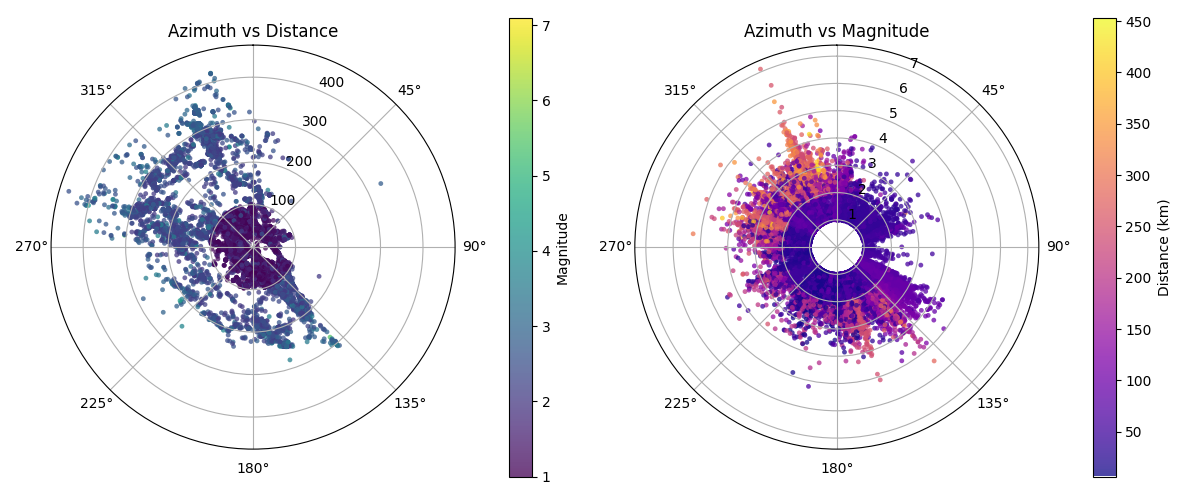

In [5]:
# Clean + prep
plot_df = cat.dropna(subset=["azimuth_deg", "distance_km", "MAG"]).copy()
plot_df["azimuth_deg"] = np.mod(plot_df["azimuth_deg"], 360.0)  # 0..360
plot_df["theta"] = np.deg2rad(plot_df["azimuth_deg"])

fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": "polar"})

# 1) Rose: azimuth vs distance (color by magnitude)
sc1 = ax[0].scatter(
    plot_df["theta"], plot_df["distance_km"],
    c=plot_df["MAG"], cmap="viridis", s=12, alpha=0.75, linewidths=0
)
ax[0].set_theta_zero_location("N")   # 0 deg at North
ax[0].set_theta_direction(-1)        # clockwise
ax[0].set_title("Azimuth vs Distance")
cb1 = plt.colorbar(sc1, ax=ax[0], pad=0.10)
cb1.set_label("Magnitude")

# 2) Rose: azimuth vs magnitude (color by distance)
sc2 = ax[1].scatter(
    plot_df["theta"], plot_df["MAG"],
    c=plot_df["distance_km"], cmap="plasma", s=12, alpha=0.75, linewidths=0
)
ax[1].set_theta_zero_location("N")
ax[1].set_theta_direction(-1)
ax[1].set_title("Azimuth vs Magnitude")
cb2 = plt.colorbar(sc2, ax=ax[1], pad=0.10)
cb2.set_label("Distance (km)")

# remove only the 0° label at North
ticks = np.arange(0, 360, 45)
labels = ["" if t == 0 else f"{t}°" for t in ticks]
for a in ax:   # ax is your 2-panel array of polar axes
    a.set_thetagrids(ticks, labels)
    
plt.tight_layout()

In [6]:
# Looking specifically at events 300 km distance
n_gt_300 = (cat["distance_km"] > 300).sum()
print(f"Events > 300 km: {n_gt_300}")

Events > 300 km: 624


In [7]:
valid = cat["distance_km"].notna().sum()
pct = 100 * n_gt_300 / valid
print(f"{n_gt_300} / {valid} = {pct:.1f}%")

624 / 49216 = 1.3%


---
Read in local catalog (<= 100 km)

In [15]:
path = "Local_Catalog/SearchResults.txt"

cat = read_scedc_txt(path)
cat["tier"] = "local"

# Remove successive events within 60 s
cat = cat.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)
dt_sec = cat["time"].diff().dt.total_seconds()
cat = cat[dt_sec.isna() | (dt_sec > 60)].reset_index(drop=True)

print(cat.shape)
cat.head()

/var/folders/wp/fkl3pnfx7yb7_xj5_dfr4p300000gp/T/ipykernel_52210/3793765149.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


(39098, 15)


,YYY/MM/DD,HH:mm:SS.ss,ET,GT,MAG,M,LAT,LON,DEPTH,Q,EVID,NPH,NGRM,time,tier
0,2014/08/01,01:19:20.07,eq,l,1.33,l,33.14550,-116.49783,10.8,A,15533393,63,1844,2014-08-01 01:19:20.070,local
1,2014/08/01,11:58:34.72,eq,l,1.36,l,34.01550,-117.15950,5.5,A,15533473,86,1952,2014-08-01 11:58:34.720,local
2,2014/08/01,12:38:05.27,eq,l,2.07,l,34.03417,-117.23467,17.8,A,15533505,161,2460,2014-08-01 12:38:05.270,local
3,2014/08/01,13:59:20.18,eq,l,1.52,l,33.80817,-116.18733,7.9,A,15533521,74,1825,2014-08-01 13:59:20.180,local
4,2014/08/01,16:38:51.38,eq,l,1.59,l,32.89850,-116.28017,1.5,A,15533545,45,1626,2014-08-01 16:38:51.380,local


In [16]:
%%time
# g.inv expects lon, lat order
fwd_az, back_az, dist_m = g.inv(
    np.full(len(cat), array_lon), np.full(len(cat), array_lat),
    cat["LON"].values, cat["LAT"].values
)

cat["distance_km"] = dist_m / 1000.0
cat["azimuth_deg"] = fwd_az        # from array -> source
cat["back_azimuth_deg"] = back_az  # from source -> array (often what arrays use)

CPU times: user 26.8 ms, sys: 5.89 ms, total: 32.7 ms
Wall time: 31.2 ms


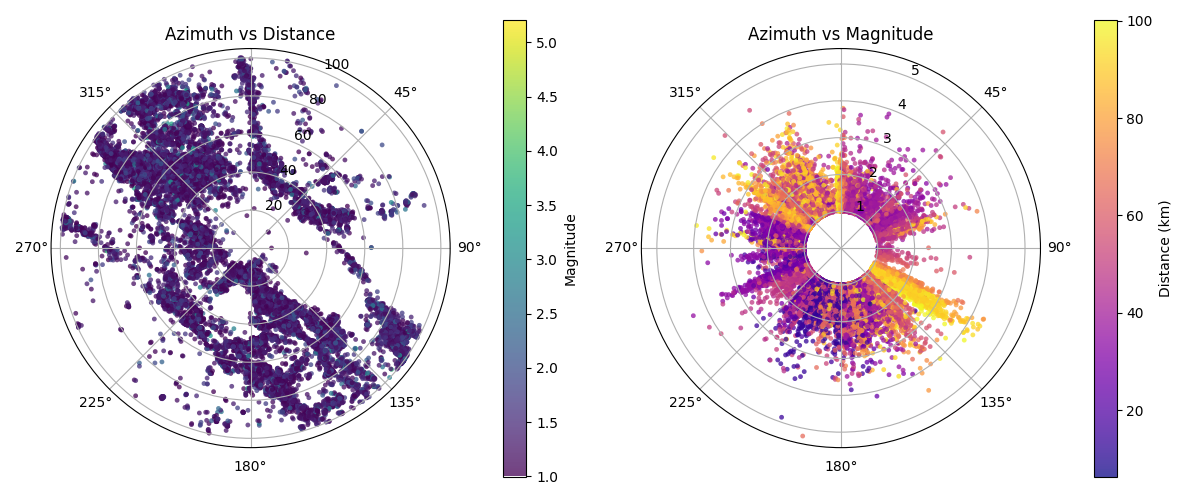

In [20]:
# Clean + prep
plot_df = cat.dropna(subset=["azimuth_deg", "distance_km", "MAG"]).copy()
plot_df["azimuth_deg"] = np.mod(plot_df["azimuth_deg"], 360.0)  # 0..360
plot_df["theta"] = np.deg2rad(plot_df["azimuth_deg"])

fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={"projection": "polar"})

# 1) Rose: azimuth vs distance (color by magnitude)
sc1 = ax[0].scatter(
    plot_df["theta"], plot_df["distance_km"],
    c=plot_df["MAG"], cmap="viridis", s=12, alpha=0.75, linewidths=0
)
ax[0].set_theta_zero_location("N")   # 0 deg at North
ax[0].set_theta_direction(-1)        # clockwise
ax[0].set_title("Azimuth vs Distance")
cb1 = plt.colorbar(sc1, ax=ax[0], pad=0.10)
cb1.set_label("Magnitude")

# 2) Rose: azimuth vs magnitude (color by distance)
sc2 = ax[1].scatter(
    plot_df["theta"], plot_df["MAG"],
    c=plot_df["distance_km"], cmap="plasma", s=12, alpha=0.75, linewidths=0
)
ax[1].set_theta_zero_location("N")
ax[1].set_theta_direction(-1)
ax[1].set_title("Azimuth vs Magnitude")
cb2 = plt.colorbar(sc2, ax=ax[1], pad=0.10)
cb2.set_label("Distance (km)")

# remove only the 0° label at North
ticks = np.arange(0, 360, 45)
labels = ["" if t == 0 else f"{t}°" for t in ticks]
for a in ax:   # ax is your 2-panel array of polar axes
    a.set_thetagrids(ticks, labels)
    
plt.tight_layout()

---
Predicting P-wave onset

In [21]:
%%time
# Array location
array_lat = 33.6106
array_lon = -116.4554

# Travel-time model
model = TauPyModel(model="iasp91")

# Make sure numeric/time types are clean
cat["LAT"] = pd.to_numeric(cat["LAT"], errors="coerce")
cat["LON"] = pd.to_numeric(cat["LON"], errors="coerce")
cat["DEPTH"] = pd.to_numeric(cat["DEPTH"], errors="coerce")
cat["time"] = pd.to_datetime(cat["time"], utc=True, errors="coerce")

def predict_p_onset(row):
    if pd.isna(row["time"]) or pd.isna(row["LAT"]) or pd.isna(row["LON"]) or pd.isna(row["DEPTH"]):
        return pd.Series([np.nan, np.nan, pd.NaT])

    dist_deg = locations2degrees(row["LAT"], row["LON"], array_lat, array_lon)

    # Include common crustal/regional P phases so local events still work
    arrivals = model.get_travel_times(
        source_depth_in_km=max(row["DEPTH"], 0.0),
        distance_in_degree=dist_deg,
        phase_list=["P", "p", "Pg", "Pn"]
    )

    if len(arrivals) == 0:
        return pd.Series([dist_deg, np.nan, pd.NaT])

    ttp = arrivals[0].time  # first (earliest) P-type arrival in seconds
    onset = row["time"] + pd.to_timedelta(ttp, unit="s")
    return pd.Series([dist_deg, ttp, onset])

cat[["distance_deg", "p_travel_time_s", "p_pred_onset"]] = cat.apply(predict_p_onset, axis=1)

# Ensure UTC-aware timestamp column
cat["p_pred_onset"] = pd.to_datetime(cat["p_pred_onset"], utc=True, errors="coerce")

# Window columns in UTC
cat["window_start_utc"] = cat["p_pred_onset"] - pd.to_timedelta(10, unit="s")
cat["window_end_utc"]   = cat["p_pred_onset"] + pd.to_timedelta(50, unit="s")
cat.head()

CPU times: user 3min 17s, sys: 572 ms, total: 3min 18s
Wall time: 3min 18s


,YYY/MM/DD,HH:mm:SS.ss,ET,GT,MAG,M,LAT,LON,DEPTH,Q,...,time,tier,distance_km,azimuth_deg,back_azimuth_deg,distance_deg,p_travel_time_s,p_pred_onset,window_start_utc,window_end_utc
0,2014/08/01,01:19:20.07,eq,l,1.33,l,33.14550,-116.49783,10.8,A,...,2014-08-01 01:19:20.070000+00:00,local,51.866585,-175.631911,4.344746,0.466448,9.126880,2014-08-01 01:19:29.196880007+00:00,2014-08-01 01:19:19.196880007+00:00,2014-08-01 01:20:19.196880007+00:00
1,2014/08/01,11:58:34.72,eq,l,1.36,l,34.01550,-117.15950,5.5,A,...,2014-08-01 11:58:34.720000+00:00,local,79.110480,-55.116266,124.491908,0.711458,13.666706,2014-08-01 11:58:48.386706164+00:00,2014-08-01 11:58:38.386706164+00:00,2014-08-01 11:59:38.386706164+00:00
2,2014/08/01,12:38:05.27,eq,l,2.07,l,34.03417,-117.23467,17.8,A,...,2014-08-01 12:38:05.270000+00:00,local,86.024977,-56.588004,122.978231,0.773642,14.930915,2014-08-01 12:38:20.200915382+00:00,2014-08-01 12:38:10.200915382+00:00,2014-08-01 12:39:10.200915382+00:00
3,2014/08/01,13:59:20.18,eq,l,1.52,l,33.80817,-116.18733,7.9,A,...,2014-08-01 13:59:20.180000+00:00,local,33.128176,48.385578,-131.465648,0.297929,5.868464,2014-08-01 13:59:26.048464340+00:00,2014-08-01 13:59:16.048464340+00:00,2014-08-01 14:00:16.048464340+00:00
4,2014/08/01,16:38:51.38,eq,l,1.59,l,32.89850,-116.28017,1.5,A,...,2014-08-01 16:38:51.380000+00:00,local,80.840908,168.323953,-11.579956,0.727020,13.938758,2014-08-01 16:39:05.318757728+00:00,2014-08-01 16:38:55.318757728+00:00,2014-08-01 16:39:55.318757728+00:00


In [22]:
%%time
# Keep this for FDSN use (timezone-aware UTC)
cat["window_start_utc"]
cat["window_end_utc"]

# Keep datetime columns for calculations; add formatted text columns for queries/export
cat["window_start_utc"] = cat["window_start_utc"].dt.strftime("%Y-%m-%dT%H:%M:%S.%f").str[:-3]
cat["window_end_utc"]   = cat["window_end_utc"].dt.strftime("%Y-%m-%dT%H:%M:%S.%f").str[:-3]

# Only for Excel export
cat_xlsx = cat.copy()
for col in cat_xlsx.select_dtypes(include=["datetimetz"]).columns:
    cat_xlsx[col] = cat_xlsx[col].dt.tz_convert("UTC").dt.tz_localize(None)
cat_xlsx.to_excel("Local_Catalog/PFO_Local_Catalog.xlsx", index=False)

CPU times: user 7.04 s, sys: 93.2 ms, total: 7.13 s
Wall time: 7.22 s
